# M5 *(Model Tree)*

### Árboles de modelo para regresión mediante regresiones lineales locales

## 1. Descripción del algoritmo

El algoritmo **M5**, introducido por Quinlan, pertenece a la familia de los **árboles de modelo** *(model trees)* y está concebido para problemas de **regresión supervisada**.

A diferencia de un árbol de regresión convencional, que asigna un valor constante a cada hoja, M5 ajusta en cada hoja un **modelo de regresión lineal**. De este modo combina dos paradigmas complementarios:

1. **Particionamiento jerárquico del espacio de entrada**, propio de los árboles de decisión, que segmenta el dominio en regiones homogéneas.
2. **Regresión lineal local**, que modela la relación entre las variables predictoras y la respuesta dentro de cada región.

Esta arquitectura permite aproximar relaciones globalmente no lineales mediante un conjunto de modelos lineales definidos por tramos, conservando una interpretabilidad razonable y una capacidad de ajuste superior a la de un árbol de regresión simple.

## 2. Publicación que propuso el algoritmo

### BibTeX — M5 original
```bibtex
@inproceedings{quinlan1992learning,
  title     = {Learning with Continuous Classes},
  author    = {Quinlan, Ross J.},
  booktitle = {Proceedings of the 5th Australian Joint Conference on Artificial Intelligence},
  pages     = {343--348},
  year      = {1992},
  publisher = {World Scientific},
  address   = {Singapore}
}
```

### BibTeX — M5' / reconstrucción posterior
```bibtex
@inproceedings{wang1997induction,
  title     = {Induction of Model Trees for Predicting Continuous Classes},
  author    = {Wang, Yong and Witten, Ian H.},
  booktitle = {Poster Papers of the 9th European Conference on Machine Learning},
  year      = {1997},
  publisher = {Springer}
}
```

### Referencias APA
- Quinlan, R. J. (1992). *Learning with continuous classes*. Proceedings of the 5th Australian Joint Conference on Artificial Intelligence, 343–348.
- Wang, Y., & Witten, I. H. (1997). *Induction of model trees for predicting continuous classes*. Poster Papers of the 9th European Conference on Machine Learning.

## 3. Tipo de modelo

| Dimensión | Clasificación para M5 |
|---|---|
| **Método de aprendizaje** | Supervisado |
| **Tipo de problema** | Regresión |
| **Por parámetros** | Híbrido: estructura no paramétrica + regresiones lineales paramétricas en hojas |
| **Datos al entrenar** | Offline / batch |
| **Resultado del entrenamiento** | Basado en modelo: árbol con modelos lineales locales |
| **Familia de algoritmos** | Regression / Decision Trees |

## 4. Algoritmo de entrenamiento

M5 induce un árbol recursivamente. Para elegir divisiones, usa una reducción de variabilidad de la variable objetivo.

### Reducción de desviación estándar
Una forma común de expresar el criterio de división es:

$$
SDR = sd(T) - \sum_i \frac{|T_i|}{|T|} sd(T_i)
$$

Donde:
- $T$ es el conjunto actual.
- $T_i$ son los subconjuntos generados por una división.
- $sd(\cdot)$ es la desviación estándar de la variable objetivo.

### Proceso general
1. Buscar la división que más reduzca la desviación estándar del objetivo.
2. Dividir el conjunto de datos en subconjuntos.
3. Repetir recursivamente mientras exista mejora suficiente.
4. En cada hoja, ajustar una **regresión lineal**.
5. Aplicar poda y suavizado en la versión completa del algoritmo.

> Nota: en esta notebook se implementa una versión didáctica tipo M5: división por SDR + regresión lineal por hoja. No implementa toda la poda/suavizado del M5 original.

## 5. Tipos de entrada

- Datos tabulares estructurados.
- Variables predictoras numéricas; las categóricas deben codificarse previamente.
- Variable objetivo continua o numérica.
- Dataset con suficientes observaciones por hoja para ajustar regresiones lineales locales.

## 6. Casos de uso

| Área | Ejemplo |
|---|---|
| Finanzas | Predicción de precios, riesgo o ingresos |
| Energía | Predicción de demanda eléctrica o consumo |
| Industria | Estimación de rendimiento, fallas o tiempos de proceso |
| Hidrología / ingeniería | Predicción de caudales, erosión o profundidad de socavación |
| Salud | Estimación de indicadores clínicos continuos |
| Retail | Predicción de ventas o demanda |

## 7. Supuestos y restricciones

### Supuestos
- La variable objetivo es continua.
- Dentro de cada región del espacio de entrada, la relación puede aproximarse con un modelo lineal.
- Hay suficientes datos en cada hoja para estimar los coeficientes de regresión.

### Restricciones
- Puede sobreajustar si el árbol crece demasiado.
- Las regresiones locales pueden ser inestables con pocas muestras por hoja.
- Requiere tratamiento previo de datos faltantes y variables categóricas.
- Su implementación completa es más compleja que un árbol de regresión convencional porque incluye poda y suavizado.

## 8. Source code — implementación simplificada tipo M5 desde cero

El código siguiente construye un árbol con:

- División por **Standard Deviation Reduction (SDR)**.
- Regresión lineal en cada hoja.
- Predicción recorriendo el árbol hasta la hoja correspondiente.

In [ ]:
# ============================================================
# Instalación opcional para Colab / Anaconda
# ============================================================
# !pip install numpy pandas scikit-learn matplotlib

In [9]:
# ============================================================
# PASO 1: Importar librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

print('Librerías importadas correctamente')

Matplotlib is building the font cache; this may take a moment.


Librerías importadas correctamente


In [10]:
# ============================================================
# PASO 2: Definir una implementación simple tipo M5
# ============================================================
class SimpleM5Regressor:
    # Implementación didáctica tipo M5.
    # - Divide nodos usando Standard Deviation Reduction (SDR).
    # - Ajusta una regresión lineal en cada hoja.
    # - No incluye poda ni suavizado completo del M5 original.

    def __init__(self, max_depth=3, min_samples_split=40, min_samples_leaf=20,
                 min_improvement=1e-6, max_thresholds=25):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_improvement = min_improvement
        self.max_thresholds = max_thresholds

    def fit(self, X, y, feature_names=None):
        self.X_ = np.asarray(X, dtype=float)
        self.y_ = np.asarray(y, dtype=float)
        self.feature_names_ = list(feature_names) if feature_names is not None else [f'x{i}' for i in range(self.X_.shape[1])]
        self.root_ = self._build_tree(self.X_, self.y_, depth=0)
        return self

    def _fit_leaf_model(self, X, y):
        model = LinearRegression()
        model.fit(X, y)
        return model

    def _candidate_thresholds(self, values):
        unique_values = np.unique(values)
        if len(unique_values) <= 1:
            return []

        midpoints = (unique_values[:-1] + unique_values[1:]) / 2.0

        # Para evitar demasiados umbrales, se toman percentiles si hay muchos valores únicos.
        if len(midpoints) > self.max_thresholds:
            percentiles = np.linspace(0, 100, self.max_thresholds + 2)[1:-1]
            midpoints = np.unique(np.percentile(values, percentiles))

        return midpoints

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        parent_std = np.std(y)
        best = None

        for feature_index in range(n_features):
            thresholds = self._candidate_thresholds(X[:, feature_index])

            for threshold in thresholds:
                left_mask = X[:, feature_index] <= threshold
                right_mask = ~left_mask

                n_left = int(left_mask.sum())
                n_right = int(right_mask.sum())

                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                weighted_std = (n_left / n_samples) * np.std(y[left_mask]) + (n_right / n_samples) * np.std(y[right_mask])
                sdr = parent_std - weighted_std

                if best is None or sdr > best['sdr']:
                    best = {
                        'feature_index': feature_index,
                        'threshold': float(threshold),
                        'sdr': float(sdr),
                        'left_mask': left_mask,
                        'right_mask': right_mask
                    }

        return best

    def _build_tree(self, X, y, depth):
        node = {
            'depth': depth,
            'n_samples': len(y),
            'mean_value': float(np.mean(y)),
            'std_value': float(np.std(y)),
            'is_leaf': False
        }

        should_stop = (
            depth >= self.max_depth or
            len(y) < self.min_samples_split or
            np.std(y) == 0
        )

        split = None if should_stop else self._best_split(X, y)

        if should_stop or split is None or split['sdr'] <= self.min_improvement:
            node['is_leaf'] = True
            node['model'] = self._fit_leaf_model(X, y)
            return node

        node['feature_index'] = split['feature_index']
        node['feature_name'] = self.feature_names_[split['feature_index']]
        node['threshold'] = split['threshold']
        node['sdr'] = split['sdr']
        node['left'] = self._build_tree(X[split['left_mask']], y[split['left_mask']], depth + 1)
        node['right'] = self._build_tree(X[split['right_mask']], y[split['right_mask']], depth + 1)
        return node

    def _predict_row(self, row, node):
        while not node['is_leaf']:
            if row[node['feature_index']] <= node['threshold']:
                node = node['left']
            else:
                node = node['right']
        return float(node['model'].predict(row.reshape(1, -1))[0])

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_row(row, self.root_) for row in X])

    def print_rules(self, node=None, indent=''):
        if node is None:
            node = self.root_

        if node['is_leaf']:
            model = node['model']
            print(indent + f"Hoja: n={node['n_samples']}, media={node['mean_value']:.2f}, intercepto={model.intercept_:.2f}")
            return

        feature = node['feature_name']
        threshold = node['threshold']
        print(indent + f"SI {feature} <= {threshold:.4f}  [SDR={node['sdr']:.4f}, n={node['n_samples']}]")
        self.print_rules(node['left'], indent + '   ')
        print(indent + f"SI {feature} >  {threshold:.4f}")
        self.print_rules(node['right'], indent + '   ')

In [11]:
# ============================================================
# PASO 3: Cargar dataset de regresión
# ============================================================
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

print('Shape:', X.shape)
print('Variable objetivo: progreso de diabetes en un año')
X.head()

Shape: (442, 10)
Variable objetivo: progreso de diabetes en un año


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [12]:
# ============================================================
# PASO 4: División Train / Test
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')

Train: 309 muestras
Test:  133 muestras


In [13]:
# ============================================================
# PASO 5: Entrenar el modelo tipo M5
# ============================================================
m5_model = SimpleM5Regressor(
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=25,
    min_improvement=0.01,
    max_thresholds=30
)

m5_model.fit(X_train, y_train, feature_names=X.columns)
print('Modelo tipo M5 entrenado con éxito')
print()
m5_model.print_rules()

Modelo tipo M5 entrenado con éxito

SI bmi <= 0.0046  [SDR=13.0241, n=309]
   SI s5 <= 0.0126  [SDR=6.5566, n=183]
      SI s3 <= 0.0242  [SDR=2.8858, n=137]
         Hoja: n=84, media=113.73, intercepto=111.85
      SI s3 >  0.0242
         Hoja: n=53, media=85.13, intercepto=68.23
   SI s5 >  0.0126
      Hoja: n=46, media=165.09, intercepto=130.70
SI bmi >  0.0046
   SI bmi <= 0.0733  [SDR=8.1218, n=126]
      SI bp <= 0.0012  [SDR=4.9090, n=101]
         Hoja: n=43, media=160.05, intercepto=202.42
      SI bp >  0.0012
         Hoja: n=58, media=210.98, intercepto=168.37
   SI bmi >  0.0733
      Hoja: n=25, media=271.12, intercepto=228.89


In [14]:
# ============================================================
# PASO 6: Evaluación del modelo
# ============================================================
def regression_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        'Modelo': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse,
        'R2': r2_score(y_true, y_pred)
    }

m5_pred = m5_model.predict(X_test)

# Comparación contra modelos base
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

tree_model = DecisionTreeRegressor(max_depth=3, min_samples_leaf=25, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

results = pd.DataFrame([
    regression_metrics('Regresión lineal global', y_test, linear_pred),
    regression_metrics('Árbol de regresión', y_test, tree_pred),
    regression_metrics('M5 simplificado', y_test, m5_pred),
])

results

,Modelo,MAE,RMSE,R2
0,Regresión lineal global,41.919378,53.120156,0.477290
1,Árbol de regresión,45.617825,57.155669,0.394853
2,M5 simplificado,47.119968,58.531999,0.365358


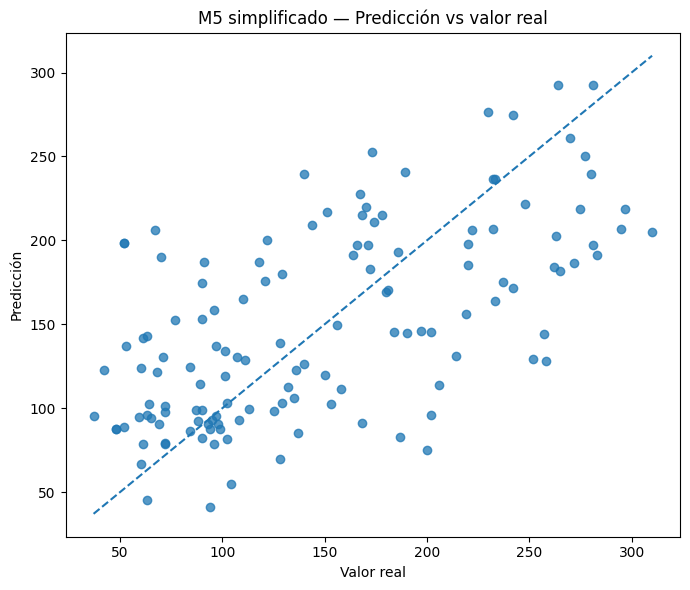

In [15]:
# ============================================================
# PASO 7: Visualizar predicciones vs valores reales
# ============================================================
plt.figure(figsize=(7, 6))
plt.scatter(y_test, m5_pred, alpha=0.75)

min_value = min(y_test.min(), m5_pred.min())
max_value = max(y_test.max(), m5_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')

plt.title('M5 simplificado — Predicción vs valor real')
plt.xlabel('Valor real')
plt.ylabel('Predicción')
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# PASO 8: Predicción de una nueva muestra
# ============================================================
new_sample = X_test.iloc[[0]]
new_prediction = m5_model.predict(new_sample)[0]

print('Nueva muestra:')
display(new_sample)
print(f'Predicción M5 simplificado: {new_prediction:.2f}')
print(f'Valor real: {y_test[0]:.2f}')

Nueva muestra:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
287,0.045341,-0.044642,-0.006206,-0.015999,0.125019,0.125198,0.019187,0.034309,0.032432,-0.00522


Predicción M5 simplificado: 155.96
Valor real: 219.00


## 9. Conclusión

La versión simplificada de M5 implementada en este documento construyó un árbol con divisiones gobernadas por la reducción de la desviación estándar *(SDR)* y ajustó regresiones lineales en sus hojas. Sobre el conjunto de prueba del dataset *diabetes*, su desempeño ($R^2 \approx 0.37$) resultó comparable al de un árbol de regresión convencional y ligeramente inferior al de la regresión lineal global, un resultado esperable dado que se omitieron la poda y el suavizado del algoritmo original y que la relación subyacente es predominantemente lineal.

M5 resulta especialmente valioso cuando se requiere un modelo más flexible que una regresión lineal global pero más transparente que una red neuronal, ya que descompone el problema en regiones y ajusta un modelo lineal interpretable en cada una. Su principal riesgo es el **sobreajuste**, que debe mitigarse controlando la profundidad del árbol, el número mínimo de observaciones por hoja y, en la formulación completa, mediante poda y suavizado de las predicciones.